# **AI Copywriter**

The workflow in this lesson generates product descriptions. A drafting node calls a large language model, a quality evaluator checks the output, and the routing function either accepts the draft and moves to finalization or loops back with feedback.

## **Step 1: State**

In [1]:
from typing import TypedDict

class DraftState(TypedDict):
    # Input — provided at invocation, never modified by nodes
    topic: str
    request_type: str
    max_retries: int

    # Control — written by the quality evaluator
    retry_count: int
    quality_passed: bool

    # Context — written by the quality evaluator for use in the next attempt
    feedback: str

    # Output — written by the drafting and finalization nodes
    draft: str
    final_output: str

## **Step 2: Setting up the Nodes**

### **The drafting node**
The drafting node has one responsibility: generate a product description. On the first attempt, feedback is empty and the prompt is standard. On subsequent attempts, feedback contains specific failure reasons written by the quality evaluator, and the prompt asks the model to address them.

In [2]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 1. Define a robust Prompt Template outside the node
# We use a system message for the base persona and a placeholder for feedback
draft_prompt = ChatPromptTemplate(
    messages=[
        ("system", 
         "You are a professional copywriter. " 
         "Write a product description for the provided topic, "
         "covering key features, benefits, and a clear call to action."
        ),
        ("human", "{topic}"),
        # This allows us to conditionally inject feedback only if it exists
        MessagesPlaceholder(variable_name="feedback_messages", optional=True)
    ]
)

In [4]:
from langchain_core.runnables import RunnableConfig

def draft_response(state: DraftState, config: RunnableConfig) -> dict:
    # 2. Retrieve the pre-injected model from config
    model = config["configurable"]["model"]
    
    # 3. Clean logic: Construct inputs dynamically
    inputs = {"topic": state["topic"]}
    
    if state["feedback"]:
        inputs["feedback_messages"] = [
            SystemMessage(content="Previous attempt did not meet quality requirements: {state['feedback']}. Please address these issues.")
        ]
    
    # 4. Use the chain
    chain = draft_prompt | model
    response = chain.invoke(inputs)
    
    return {"draft": response.content}

### **The quality evaluator node**

The quality evaluator applies two concrete criteria: minimum word count and minimum sentence count. When a criterion fails, it writes a human-readable reason into feedback. When all criteria pass, feedback is cleared.

In [17]:
THRESHOLDS = {
    "short":    {"min_words": 20, "min_sentences": 2},
    "detailed": {"min_words": 60, "min_sentences": 4},
}
DEFAULT_THRESHOLD = {"min_words": 40, "min_sentences": 3}

def evaluate_quality(state: DraftState) -> dict:
    thresholds = THRESHOLDS.get(state["request_type"], DEFAULT_THRESHOLD)
    min_words = thresholds["min_words"]
    min_sentences = thresholds["min_sentences"]

    draft = state["draft"].strip()
    word_count = len(draft.split())
    sentence_count = sum(draft.count(p) for p in [".", "!", "?"])

    issues = []
    if word_count < min_words:
        issues.append(f"Too short ({word_count} words; minimum is {min_words}).")
    if sentence_count < min_sentences:
        issues.append(
            f"Too few sentences ({sentence_count}; minimum is {min_sentences})."
        )

    passed = len(issues) == 0
    return {
        "quality_passed": passed,
        "retry_count": state["retry_count"] + 1,
        "feedback": " ".join(issues) if issues else "",
    }

### **The finalization node**

The finalization node formats the accepted draft into a deliverable output. It reads quality_passed from state to label the output appropriately, so the caller can distinguish between a draft that fully passed quality and one that was accepted because the retry limit was reached.

In [18]:
def finalize_output(state: DraftState) -> dict:
    attempts = state["retry_count"]
    if state["quality_passed"]:
        quality_note = f"passed (attempt {attempts} of {state['max_retries']})"
    else:
        quality_note = f"accepted after max retries ({attempts} attempt(s))"

    header = (
        f"=== Product Description ===\n"
        f"Topic  : {state['topic']}\n"
        f"Quality: {quality_note}\n"
        f"===========================\n\n"
    )
    return {"final_output": header + state["draft"].strip()}

## **Step 3: Building the Workflow**

### **The routing function**

The routing function checks the stop conditions in a deliberate order. Quality is checked first because it is the preferred exit. The retry count is checked second because it is the fallback exit. If neither condition is met, the function returns the drafting node name to continue the loop.

In [19]:
from typing import Literal

def route_after_evaluation(
    state: DraftState,
) -> Literal["finalize_output", "draft_response"]:
    if state["quality_passed"]:
        return "finalize_output"
    if state["retry_count"] >= state["max_retries"]:
        return "finalize_output"
    return "draft_response"

### **Graph assembly**

The loop-back edge is what makes this graph different from the linear workflows in previous lessons. The edge from evaluate_quality back to draft_response creates a cycle, and the routing function is what keeps that cycle from running forever.

In [20]:
from langgraph.graph import END, START, StateGraph

def build_graph():
    graph = StateGraph(DraftState)
    graph.add_node("draft_response", draft_response)
    graph.add_node("evaluate_quality", evaluate_quality)
    graph.add_node("finalize_output", finalize_output)

    graph.add_edge(START, "draft_response")
    graph.add_edge("draft_response", "evaluate_quality")
    graph.add_conditional_edges("evaluate_quality", route_after_evaluation)
    graph.add_edge("finalize_output", END)

    return graph.compile()

In [21]:
workflow = build_graph()

## **Step 4: Visualizing the Graph**

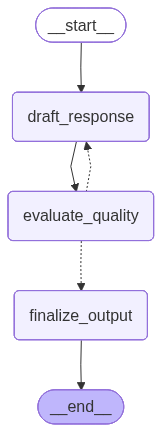

In [22]:
# Visualize the Graph
from IPython.display import Image, display

display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

## **Step 5: Running the Workflow**

### **Initializing the Chat Models**

In [23]:
from langchain_groq import ChatGroq

with open("keys/.groq_api_key.txt") as f:
    GROQ_API_KEY = f.read()

groq_chat_model = ChatGroq(
    api_key=GROQ_API_KEY, 
    model="openai/gpt-oss-120b", 
    temperature=1
)

groq_chat_model.invoke("hi").content

'Hello! How can I help you today?'

### **Defining the Test Cases**

In [24]:
cases = [
    {
        "topic": "Noise-cancelling wireless headphones", 
        "request_type": "detailed", 
        "max_retries": 3
    },
    {
        "topic": "Portable phone charger", 
        "request_type": "short", 
        "max_retries": 2
    },
]

### **Invoking the Workflow**

In [25]:
print("=== Retries and quality loops ===\n")
for case in cases:
    result = workflow.invoke({
        "topic": case["topic"],
        "request_type": case["request_type"],
        "max_retries": case["max_retries"],
        "retry_count": 0,
        "quality_passed": False,
        "feedback": "",
        "draft": "",
        "final_output": "",
    }, config={
        "configurable": {
            "model": groq_chat_model,
        }
    })
    print(result["final_output"])
    print()

=== Retries and quality loops ===

=== Product Description ===
Topic  : Noise-cancelling wireless headphones
Quality: passed (attempt 1 of 3)

## Elevate Your Audio Experience with the **Aurelia Pro X** Noise‑Cancelling Wireless Headphones  

### Why the Aurelia Pro X Is a Game‑Changer  

| **Key Feature** | **What It Means for You** |
|-----------------|---------------------------|
| **Hybrid Active Noise Cancellation (ANC)** – Dual‑mic sensors and adaptive algorithms block up to 96 % of ambient noise. | Immerse yourself in music, podcasts, or calls without distractions—whether you’re on a crowded commute, in a bustling office, or flying at 30 000 ft. |
| **Bluetooth 5.2 & Multi‑Device Pairing** – Stable, low‑latency connection up to 30 ft; pair two devices simultaneously. | Seamlessly switch from a laptop to a smartphone without re‑pairing, and enjoy crystal‑clear sound with virtually no drop‑outs. |
| **Hi‑Res Audio Drivers + Custom EQ** – 40 mm dynamic drivers tuned for a balanced 